In [1]:
import itertools
from collections import defaultdict
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import pyfaidx
import torch
import torch.nn as nn
import seaborn as sns; sns.set_style("whitegrid")
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from tqdm.auto import tqdm

from alphagenome_pytorch import AlphaGenome
from alphagenome_pytorch import layers
from alphagenome_pytorch.attribution import deeplift
from alphagenome_pytorch.utils.sequence import sequence_to_onehot_tensor

# chrombpnet-pytorch
from chrombpnet.bpnet import BPNet

# tangermeme: use memory-efficient-deeplift branch @ https://github.com/rastogiruchir/tangermeme/tree/memory-efficient-deeplift 
# to reduce memory footprint
from tangermeme.deep_lift_shap import _nonlinear, deep_lift_shap 
from tangermeme.ersatz import dinucleotide_shuffle
from tangermeme.plot import plot_logo

In [2]:
ALPHAGENOME_MODEL_PATH = "/oak/stanford/groups/akundaje/rrastogi/external_repos/alphagenome-pytorch/.models/model_fold_1.safetensors"
CHROMBPNET_MODEL_PATH = "/oak/stanford/groups/akundaje/rrastogi/chrombpnet-xl/data/chrombpnet_models/GM12878_ATAC_ENCSR637XSC/fold_0/model.chrombpnet_nobias.fold_0.ENCSR637XSC.h5"
HG38_FASTA_PATH = "/oak/stanford/groups/akundaje/rrastogi/data/genomes/ENCODE_GRCh38/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta"

# Helper functions/classes

Lightweight Region class.

In [3]:
@dataclass(frozen=True, slots=True)
class Region:
    """A genomic region using 0-indexed, half-open coordinates."""
    chrom: str
    start: int
    end: int

    def __post_init__(self):
        object.__setattr__(self, "chrom", self.chrom.replace("chr", ""))
        object.__setattr__(self, "start", int(self.start))
        object.__setattr__(self, "end", int(self.end))
    
    def resized(self, new_size: int) -> "Region":
        center = (self.start + self.end) // 2
        new_start = center - new_size // 2
        new_end = new_start + new_size
        return Region(self.chrom, new_start, new_end)
    
    @classmethod
    def from_str(cls, region_str: str) -> "Region":
        chrom, span = region_str.split(":")
        start, end = span.split("-")
        return cls(chrom, start, end)

Wrapper nn.Modules for AlphaGenome and ChromBPNet that work with tangermeme.

In [4]:
class AlphaGenomeWrapper(nn.Module):
    def __init__(
        self, 
        model: AlphaGenome, 
        modality: str, 
        track_idx: int, 
        target_length: int,
        resolution: int = 1,
        organism_idx: int = 0, # default to human
    ):
        super().__init__()
        self.model = model
        self.modality = modality
        self.track_idx = track_idx
        self.target_length = target_length
        self.resolution = resolution
        self.organism_idx = organism_idx
        self.log1p = layers.Log1p()
    
    def forward(self, x):
        x = x.transpose(1, 2) # (N, L, 4)
        organism_tensor = torch.full(
            (x.shape[0],),
            self.organism_idx,
            dtype=torch.long,
            device=x.device,
        )
        out = self.model(
            x,
            organism_tensor,
            heads=(self.modality,),
            resolutions=(self.resolution,),
            channels_last=True
        )
        atac = out[self.modality][self.resolution]
        signal = atac[:, :, self.track_idx] # (N, L)

        center_start = signal.shape[1] // 2 - self.target_length // 2
        center_end = center_start + self.target_length
        signal = signal[:, center_start:center_end].sum(dim=1) # (N,)
        return self.log1p(signal).unsqueeze(1)

In [5]:
class ChromBPNetWrapper(nn.Module):
    def __init__(self, model: BPNet):
        super().__init__()
        self.model = model
    
    def forward(self, x):
        _, pred_counts = self.model(x)
        return pred_counts

Helper functions to run DeepLIFT on AlphaGenome/ChromBPNet.

In [6]:
def _load_sequences(target_regions: list[Region], input_sequence_length: int) -> torch.Tensor:
    with pyfaidx.Fasta(HG38_FASTA_PATH) as fasta:
        one_hot_seqs = []
        for target_region in target_regions:
            input_region = target_region.resized(input_sequence_length)
            seq = fasta[f"chr{input_region.chrom}"][input_region.start:input_region.end].seq
            one_hot = sequence_to_onehot_tensor(seq).T # (4, L)
            one_hot_seqs.append(one_hot)
        one_hot_seqs = torch.stack(one_hot_seqs) # (N, 4, L)
    return one_hot_seqs

In [7]:
def run_deeplift_on_alphagenome(
    model: AlphaGenome,
    device: str,
    target_regions: list[Region],
    input_sequence_length: int,
    modality: str = "atac", 
    track_idx: int = 63, # GM12878
    resolution: int = 1,
    n_shuffles: int = 20,
    batch_size: int = 1,
    use_log_ratio_rule_for_softmax: bool = True,
    use_log_ratio_rule_for_layernorm: bool = False,
    use_local_dinucleotide_shuffling: bool = True,
):
    one_hot_seqs = _load_sequences(target_regions, input_sequence_length)
    wrapper = AlphaGenomeWrapper(model, modality, track_idx, 1000, resolution)

    
    additional_nonlinear_ops = {
        layers.QuickGELU: _nonlinear,
        layers.TanhSoftCap: _nonlinear,
        layers.SoftClip: _nonlinear,
        layers.Log1p: _nonlinear,
        nn.Softmax: (
            deeplift.softmax_log_ratio_product_rule
            if use_log_ratio_rule_for_softmax
            else deeplift.softmax_symmetric_product_rule
        ),
        layers.LayerNorm: (
            deeplift.layernorm_log_ratio_product_rule
            if use_log_ratio_rule_for_layernorm
            else deeplift.layernorm_symmetric_product_rule
        ),
        layers.BilinearOp: deeplift.bilinear_symmetric_product_rule,
    }
    return deep_lift_shap(
        wrapper,
        one_hot_seqs,
        target=0,
        batch_size=batch_size,
        references=(
            deeplift.local_dinucleotide_shuffle
            if use_local_dinucleotide_shuffling
            else dinucleotide_shuffle
        ),
        n_shuffles=n_shuffles,
        warning_threshold=1e-3,
        additional_nonlinear_ops=additional_nonlinear_ops,
        uncached_nonlinear_ops={layers.QuickGELU},
        device=device,
        random_state=0
    )


def run_deeplift_on_chrombpnet(
    model: AlphaGenome,
    device: str,
    target_regions: list[Region],
):
    one_hot_seqs = _load_sequences(target_regions, input_sequence_length=2114)
    wrapper = ChromBPNetWrapper(model)
    return deep_lift_shap(
        wrapper,
        one_hot_seqs,
        target=0,
        batch_size=1,
        n_shuffles=20,
        warning_threshold=1e-3,
        device=device,
        random_state=42
    )

Helper functions to run gradient x input on AlphaGenome/ChromBPNet.

In [8]:
def run_gradient_x_input_on_alphagenome(
    model: AlphaGenome,
    device: str,
    target_regions: list[Region],
    input_sequence_length: int,
    modality: str = "atac", 
    track_idx: int = 63, # GM12878
    resolution: int = 1,
    batch_size: int = 1,
):
    one_hot_seqs = _load_sequences(target_regions, input_sequence_length)
    wrapper = AlphaGenomeWrapper(model, modality, track_idx, 1000, resolution)
    wrapper = wrapper.to(device).eval()

    attrs = []
    for start in range(0, one_hot_seqs.shape[0], batch_size):
        x = one_hot_seqs[start : start + batch_size].to(device).float()
        x = x.requires_grad_(True)

        wrapper.zero_grad(set_to_none=True)
        y = wrapper(x)[:, 0].sum()
        y.backward()

        grad = x.grad - x.grad.mean(dim=1, keepdim=True) # (N, 4, L)
        attr = x * grad
        attrs.append(attr.detach().cpu())
    return torch.cat(attrs, dim=0)


def run_gradient_x_input_on_chrombpnet(
    model: BPNet,
    device: str,
    target_regions: list[Region],
    batch_size: int = 1,
):
    one_hot_seqs = _load_sequences(target_regions, input_sequence_length=2114)
    wrapper = ChromBPNetWrapper(model)
    wrapper = wrapper.to(device).eval()

    attrs = []
    for start in range(0, one_hot_seqs.shape[0], batch_size):
        x = one_hot_seqs[start : start + batch_size].to(device).float()
        x = x.requires_grad_(True)

        wrapper.zero_grad(set_to_none=True)
        y = wrapper(x)[:, 0].sum()
        y.backward()

        grad = x.grad - x.grad.mean(dim=1, keepdim=True) # (N, 4, L)
        attr = x * grad
        attrs.append(attr.detach().cpu())
    return torch.cat(attrs, dim=0)

Helper function to plot a logo using the center of an attribution array.

In [9]:
def plot_logo_center(
    attributions: torch.Tensor, 
    center_window_size: int = 200, 
    ax: Optional[plt.Axes] = None
):
    assert attributions.ndim == 2 # (4, L)
    assert attributions.shape[0] == 4

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 2))
    
    L = attributions.shape[1]
    start = L // 2 - center_window_size // 2
    end = start + center_window_size
    plot_logo(attributions[:, start:end], ax=ax)

Helper function to compare attributions. Because models may have different input sequence lengths, compare attributions only in center

In [10]:
def compare_attributions(
    attrs1: torch.Tensor,
    attrs2: torch.Tensor,
    center_window_size: int
):
    assert attrs1.ndim == 2 and attrs1.shape[0] == 4
    assert attrs2.ndim == 2 and attrs2.shape[0] == 4
    
    attrs1 = attrs1.sum(dim=0) # (L,)
    attrs2 = attrs2.sum(dim=0) # (L,)

    center_start1 = attrs1.shape[0] // 2 - center_window_size // 2
    center_end1 = center_start1 + center_window_size
    attrs1_center = attrs1[center_start1:center_end1]

    center_start2 = attrs2.shape[0] // 2 - center_window_size // 2
    center_end2 = center_start2 + center_window_size
    attrs2_center = attrs2[center_start2:center_end2]
    return pearsonr(attrs1_center, attrs2_center)[0]

# Setup

Load models.

In [11]:
assert torch.cuda.is_available()
alphagenome_device = "cuda:0"
alphagenome = AlphaGenome.from_pretrained(ALPHAGENOME_MODEL_PATH, device=alphagenome_device)
chrombpnet_device = "cuda:1" # use a separate GPU to avoid OOM issues on AlphaGenome GPU
chrombpnet = BPNet.from_keras(CHROMBPNET_MODEL_PATH).eval()

Get target peaks that are not trained on by either fold-0 ChromBPNet or fold-1 AlphaGenome

In [12]:
target_regions = [
    Region.from_str(x) for x in [
        "8:41828062-41829062",
        "20:1965083-1966083",
        "8:110893416-110894416",
        "8:55310915-55311915",
        "8:101205724-101206724",
        "8:39218831-39219831",
        "8:143733301-143734301",
        "8:142717810-142718810",
        "8:59146483-59147483",
        "8:37762353-37763353",
        "8:113776923-113777923",
        "8:136481152-136482152",
        "8:38787694-38788694",
        "8:104329536-104330536",
        "8:120634295-120635295",
        "8:26595284-26596284",
        "8:143617388-143618388",
        "8:8634378-8635378",
        "20:16317715-16318715",
        "20:1391406-1392406",
        "8:12014747-12015747",
        "8:37899073-37900073",
        "20:10351146-10352146",
        "8:37995946-37996946",
        "8:120291391-120292391"
    ]
]

# Initial run

Let's make sure we can run DeepLIFT on AlphaGenome and compare attributions for a single example to ChromBPNet.

In [13]:
ag_deeplift = run_deeplift_on_alphagenome(
    model=alphagenome,
    device=alphagenome_device,
    target_regions=target_regions[0:1],
    input_sequence_length=2**16,
    use_local_dinucleotide_shuffling=True,
)

In [14]:
chrombpnet_deeplift = run_deeplift_on_chrombpnet(
    model=chrombpnet,
    device=chrombpnet_device,
    target_regions=target_regions[0:1],
)

In [15]:
ag_gradient_x_input = run_gradient_x_input_on_alphagenome(
    model=alphagenome,
    device=alphagenome_device,
    target_regions=target_regions[0:1],
    input_sequence_length=2**16,
)

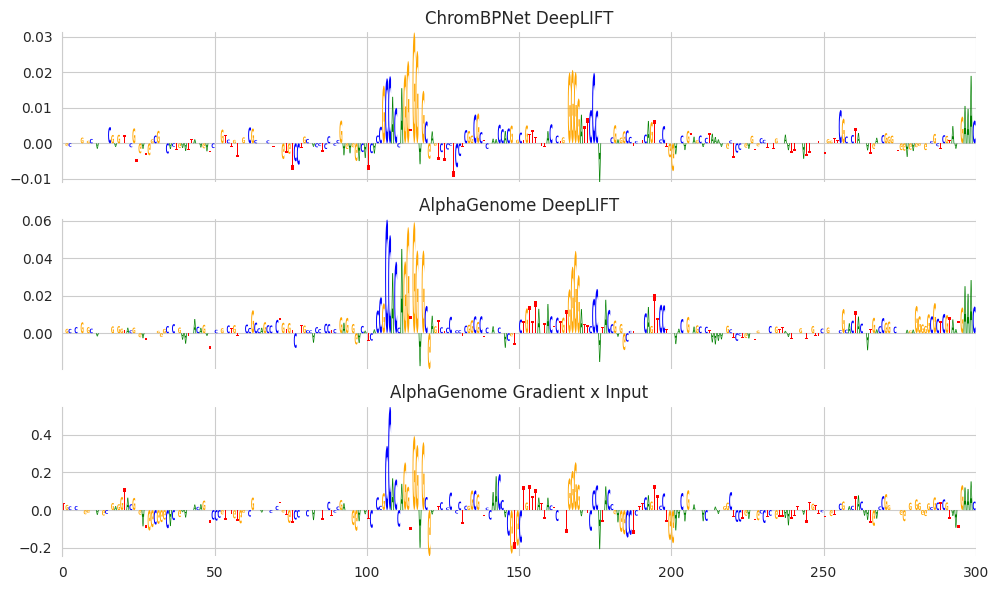

In [17]:
fig, axs = plt.subplots(nrows=3, figsize=(10, 6), sharex=True)
plot_logo_center(chrombpnet_deeplift[0], center_window_size=300, ax=axs[0])
axs[0].set_title("ChromBPNet DeepLIFT")
plot_logo_center(ag_deeplift[0], center_window_size=300, ax=axs[1])
axs[1].set_title("AlphaGenome DeepLIFT")
plot_logo_center(ag_gradient_x_input[0], center_window_size=300, ax=axs[2])
axs[2].set_title("AlphaGenome Gradient x Input")
plt.tight_layout()
plt.show()

AlphaGenome's DeepLIFT and ChromBPNet's DeepLIFT are highly aligned, while AlphaGenome's gradient x input is not, as we would expect.

# Systematically compare ChromBPNet and AlphaGenome attributions

Let's assume ChromBPNet's DeepLIFT attributions are ground truth. Compute Pearson correlations between ChromBPNet DeepLIFT attributions to those generated using AG DeepLIFT and AG Gradient x Input. Correlations are only computed within the 1000 bp of the target interval.

In [18]:
pearsons = defaultdict(list)
for i in tqdm(range(len(target_regions))):
    ag_deeplift = run_deeplift_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
        use_local_dinucleotide_shuffling=True,
    )[0]
    ag_gradient_x_input = run_gradient_x_input_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
    )[0]
    chrombpnet_deeplift = run_deeplift_on_chrombpnet(
        model=chrombpnet,
        device=chrombpnet_device,
        target_regions=target_regions[i:i+1],
    )[0]
    
    pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT"].append(
        compare_attributions(ag_deeplift, chrombpnet_deeplift, center_window_size=1_000)
    )
    pearsons["ChromBPNet DeepLIFT v. AG gradient x input"].append(
        compare_attributions(ag_gradient_x_input, chrombpnet_deeplift, center_window_size=1_000)
    )

  0%|          | 0/25 [00:00<?, ?it/s]

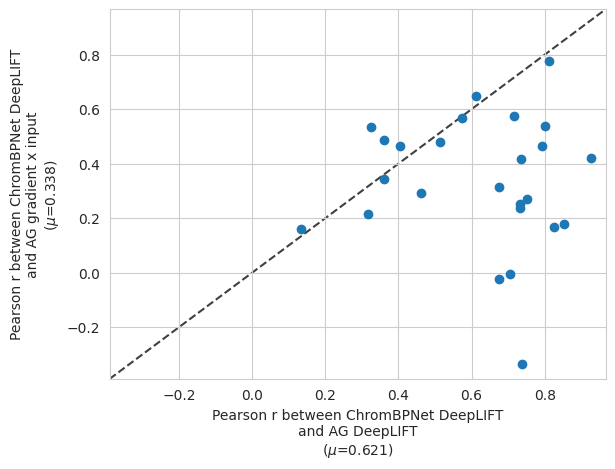

In [19]:
fig, ax = plt.subplots()
ax.scatter(
    x=pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT"], 
    y=pearsons["ChromBPNet DeepLIFT v. AG gradient x input"],
)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]), # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]), # max of both axes
]
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)

mean_x = np.mean(pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT"])
mean_y = np.mean(pearsons["ChromBPNet DeepLIFT v. AG gradient x input"])
ax.set_xlabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG DeepLIFT" + "\n" + rf"($\mu$={mean_x:.3f})")
ax.set_ylabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG gradient x input" + "\n" + rf"($\mu$={mean_y:.3f})")
plt.show()

ChromBPNet DeepLIFT is much more similar to AG DeepLIFT than AG gradient x input, as we anecdotally observed above.

# Determine impact of local v. global shuffling 

Assume ChromBPNet DeepLIFT is ground truth. Run AlphaGenome DeepLIFT with either local or global shuffling and compare attributions to ChromBPNet.

In [21]:
pearsons = defaultdict(list)
for i in tqdm(range(len(target_regions))):
    ag_local_deeplift = run_deeplift_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
        use_local_dinucleotide_shuffling=True,
    )[0]
    ag_global_deeplift = run_deeplift_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
        use_local_dinucleotide_shuffling=False,
    )[0]
    chrombpnet_deeplift = run_deeplift_on_chrombpnet(
        model=chrombpnet,
        device=chrombpnet_device,
        target_regions=target_regions[i:i+1],
    )[0]
    
    pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (local shuffling)"].append(
        compare_attributions(ag_local_deeplift, chrombpnet_deeplift, center_window_size=1_000)
    )
    pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (global shuffling)"].append(
        compare_attributions(ag_global_deeplift, chrombpnet_deeplift, center_window_size=1_000)
    )

  0%|          | 0/25 [00:00<?, ?it/s]

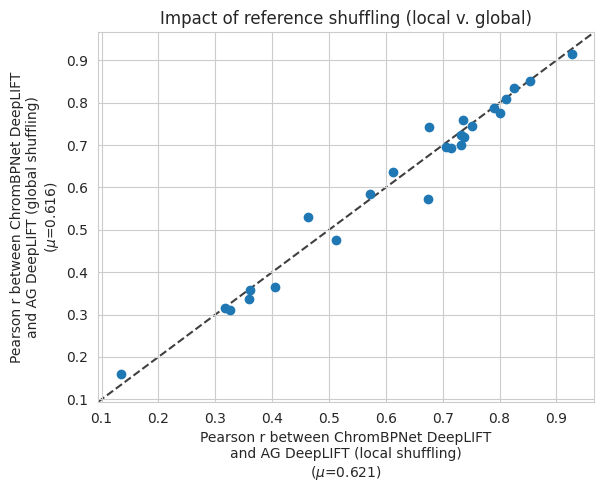

In [22]:
fig, ax = plt.subplots()
ax.scatter(
    x=pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (local shuffling)"], 
    y=pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (global shuffling)"],
)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]), # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]), # max of both axes
]
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)

mean_x = np.mean(pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (local shuffling)"])
mean_y = np.mean(pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (global shuffling)"])
ax.set_xlabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG DeepLIFT (local shuffling)" + "\n" + rf"($\mu$={mean_x:.3f})")
ax.set_ylabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG DeepLIFT (global shuffling)" + "\n" + rf"($\mu$={mean_y:.3f})")
ax.set_title("Impact of reference shuffling (local v. global)")
plt.show()

Local shuffling seems to work better, as expected.

# Determine impact of LayerNorm rule.

Assume ChromBPNet DeepLIFT is ground truth. Run AlphaGenome DeepLIFT with both of the two LayerNorm rules and compare to ChromBPNet.

In [23]:
pearsons = defaultdict(list)
for i in tqdm(range(len(target_regions))):
    ag_symmetric_product_deeplift = run_deeplift_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
        use_local_dinucleotide_shuffling=True,
        use_log_ratio_rule_for_layernorm=False,
    )[0]
    ag_log_ratio_product_deeplift = run_deeplift_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
        use_local_dinucleotide_shuffling=True,
        use_log_ratio_rule_for_layernorm=True,
    )[0]
    chrombpnet_deeplift = run_deeplift_on_chrombpnet(
        model=chrombpnet,
        device=chrombpnet_device,
        target_regions=target_regions[i:i+1],
    )[0]
    
    pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (symmetric product LayerNorm)"].append(
        compare_attributions(ag_symmetric_product_deeplift, chrombpnet_deeplift, center_window_size=1_000)
    )
    pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (log-ratio product LayerNorm)"].append(
        compare_attributions(ag_log_ratio_product_deeplift, chrombpnet_deeplift, center_window_size=1_000)
    )

  0%|          | 0/25 [00:00<?, ?it/s]

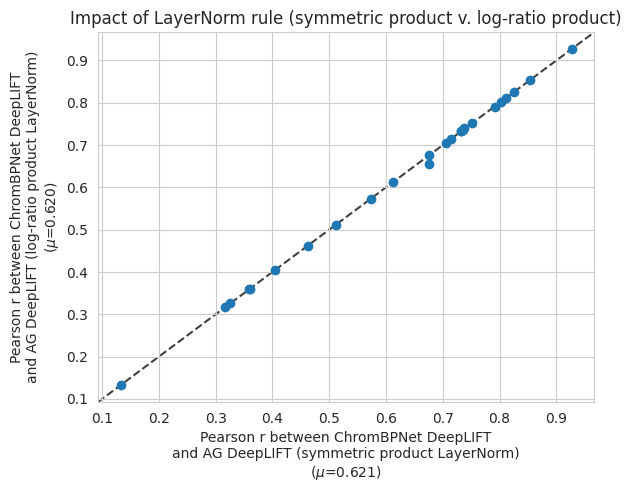

In [24]:
fig, ax = plt.subplots()
ax.scatter(
    x=pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (symmetric product LayerNorm)"], 
    y=pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (log-ratio product LayerNorm)"],
)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]), # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]), # max of both axes
]
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)

mean_x = np.mean(pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (symmetric product LayerNorm)"])
mean_y = np.mean(pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (log-ratio product LayerNorm)"])
ax.set_xlabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG DeepLIFT (symmetric product LayerNorm)" + "\n" + rf"($\mu$={mean_x:.3f})")
ax.set_ylabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG DeepLIFT (log-ratio product LayerNorm)" + "\n" + rf"($\mu$={mean_y:.3f})")
ax.set_title("Impact of LayerNorm rule (symmetric product v. log-ratio product)")
plt.show()

# Determine impact of softmax rule

In [25]:
pearsons = defaultdict(list)
for i in tqdm(range(len(target_regions))):
    ag_symmetric_product_deeplift = run_deeplift_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
        use_local_dinucleotide_shuffling=True,
        use_log_ratio_rule_for_softmax=False,
    )[0]
    ag_log_ratio_product_deeplift = run_deeplift_on_alphagenome(
        model=alphagenome,
        device=alphagenome_device,
        target_regions=target_regions[i:i+1],
        input_sequence_length=2**14,
        use_local_dinucleotide_shuffling=True,
        use_log_ratio_rule_for_softmax=True,
    )[0]
    chrombpnet_deeplift = run_deeplift_on_chrombpnet(
        model=chrombpnet,
        device=chrombpnet_device,
        target_regions=target_regions[i:i+1],
    )[0]
    
    pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (symmetric product softmax)"].append(
        compare_attributions(ag_symmetric_product_deeplift, chrombpnet_deeplift, center_window_size=1_000)
    )
    pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (log-ratio product softmax)"].append(
        compare_attributions(ag_log_ratio_product_deeplift, chrombpnet_deeplift, center_window_size=1_000)
    )

  0%|          | 0/25 [00:00<?, ?it/s]

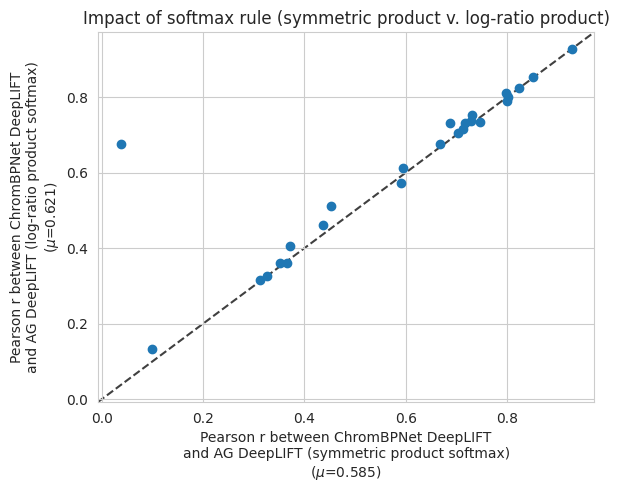

In [26]:
fig, ax = plt.subplots()
ax.scatter(
    x=pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (symmetric product softmax)"], 
    y=pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (log-ratio product softmax)"],
)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]), # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]), # max of both axes
]
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)

mean_x = np.mean(pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (symmetric product softmax)"])
mean_y = np.mean(pearsons["ChromBPNet DeepLIFT v. AG DeepLIFT (log-ratio product softmax)"])
ax.set_xlabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG DeepLIFT (symmetric product softmax)" + "\n" + rf"($\mu$={mean_x:.3f})")
ax.set_ylabel("Pearson r between ChromBPNet DeepLIFT" + "\n" "and AG DeepLIFT (log-ratio product softmax)" + "\n" + rf"($\mu$={mean_y:.3f})")
ax.set_title("Impact of softmax rule (symmetric product v. log-ratio product)")
plt.show()